# The Decision Boundary

> 📖 Book: [ch06](../../.claude/skills/ml-knowledge/chapters/ch06-logistic-regression.md) · Prev: [02](02_cost_and_gradient.ipynb) · Next: [04 One-vs-all](04_one_vs_all.ipynb)

To get a discrete class we threshold the hypothesis:

$$
h_\theta(x) \ge 0.5 \;\Rightarrow\; y = 1, \qquad h_\theta(x) < 0.5 \;\Rightarrow\; y = 0 .
$$

The sigmoid satisfies $S(z) \ge 0.5 \iff z \ge 0$, because

$$
z = 0 \Rightarrow S(z) = \tfrac12, \qquad z \to \infty \Rightarrow S(z) \to 1, \qquad z \to -\infty \Rightarrow S(z) \to 0 .
$$

With $z = \theta^Tx$:

$$
\theta^Tx \ge 0 \;\Rightarrow\; y = 1, \qquad \theta^Tx < 0 \;\Rightarrow\; y = 0 .
$$

The **decision boundary** is the set $\{x : \theta^Tx = 0\}$ that separates the region where we predict $y = 1$ from the one where we predict $y = 0$. It is a property of the hypothesis (of $\theta$), not of the data; the data are used to *fit* $\theta$.

**Example.** $\theta = (5, -1, 0)^T$: predict $y = 1$ if $5 - x_1 \ge 0$, i.e. $x_1 \le 5$. The boundary is the vertical line $x_1 = 5$; everything to its left is class 1.

More generally, the level sets $\theta^Tx = c$ are the lines where $h_\theta = S(c)$: moving the threshold $\gamma$ shifts the boundary parallel to itself.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles, make_moons

from ml.features.scaling import polynomial_features_2d, standardize
from ml.linear_models import add_bias
from ml.logistic import fit_logistic, predict, predict_proba
from ml.metrics import accuracy
from ml.visualization.plots import plot_decision_boundary

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(0)

# The hand-made example theta = (5, -1, 0)
theta = np.array([5.0, -1.0, 0.0])
Xr = rng.uniform(0, 10, size=(80, 2))
y = predict(theta, add_bias(Xr))
ax = plot_decision_boundary(lambda P: predict_proba(theta, add_bias(P)), Xr, y)
ax.axvline(5, c="k", lw=2, label=r"$\theta^Tx = 0 \iff x_1 = 5$")
ax.set_title(r"$\theta = (5, -1, 0)^T$: shading = $h_\theta(x)$")
ax.legend()
plt.show()

ValueError: 
\theta^Tx = 0 \iff x_1 = 5
              ^
ParseFatalException: Unknown symbol: \iff, found '\'  (at char 14), (line:1, col:15)

<Figure size 600x500 with 1 Axes>

## A linear boundary learned from data

Two Gaussian blobs, fit by gradient descent. The shading shows $h_\theta(x)$; the thick line is $h_\theta = 0.5$, the thin ones are other thresholds $\gamma$.

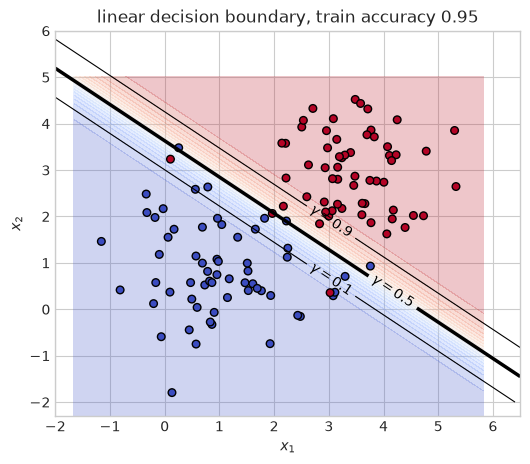

In [2]:
Xr = np.r_[rng.normal([1, 1], 0.9, size=(60, 2)), rng.normal([3.5, 3], 0.9, size=(60, 2))]
y = np.r_[np.zeros(60), np.ones(60)]
Z, transform = standardize(Xr)
theta, _ = fit_logistic(add_bias(Z), y, alpha=1.0)


def proba(P):
    return predict_proba(theta, add_bias(transform(P)))


ax = plot_decision_boundary(proba, Xr, y)
G1, G2 = np.meshgrid(np.linspace(-2, 6.5, 200), np.linspace(-2, 6, 200))
Pg = proba(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)
cs = ax.contour(G1, G2, Pg, levels=[0.1, 0.5, 0.9], colors="k", linewidths=[0.8, 2.5, 0.8])
ax.clabel(cs, fmt=lambda v: rf"$\gamma={v}$")
ax.set_title(f"linear decision boundary, train accuracy {accuracy(y, proba(Xr) >= 0.5):.2f}")
plt.show()

## Nonlinear boundaries: polynomial features again

The input to the sigmoid doesn't need to be linear in $x$. With

$$
z = \theta_0 + \theta_1x_1^2 + \theta_2x_2^2
$$

and, e.g., $\theta = (-1, 1, 1)$, we predict $y = 1$ when $x_1^2 + x_2^2 \ge 1$: the boundary is the **unit circle**. Adding higher-order monomials $x_1^ax_2^b$ lets the boundary take any shape. As always it is still linear in $\theta$, so nothing changes in the cost or the gradient.

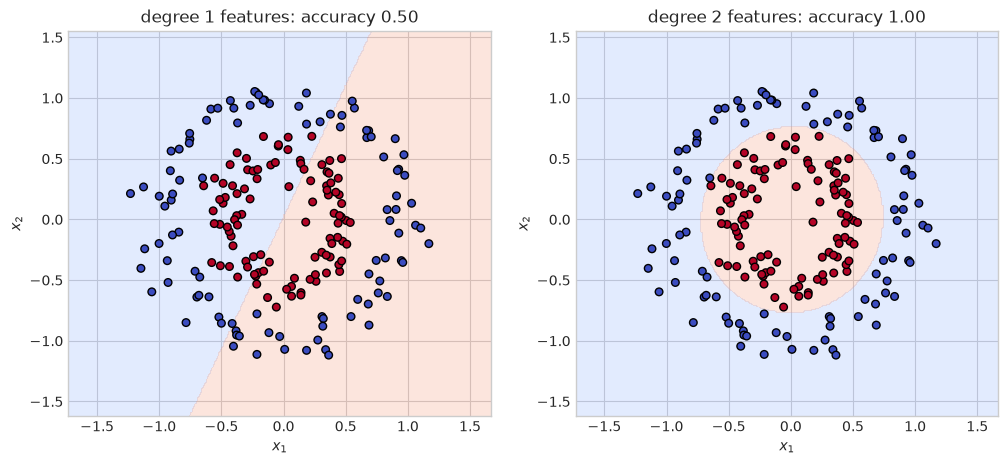

In [3]:
Xc, yc = make_circles(200, noise=0.1, factor=0.5, random_state=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, d in zip(axes, [1, 2], strict=True):
    Z, transform = standardize(polynomial_features_2d(Xc, d))
    th, _ = fit_logistic(add_bias(Z), yc, alpha=1.0, max_iter=5000)
    f = lambda P, th=th, transform=transform, d=d: predict(th, add_bias(transform(polynomial_features_2d(P, d))))  # noqa: E731
    plot_decision_boundary(f, Xc, yc, ax=ax)
    ax.set_title(f"degree {d} features: accuracy {accuracy(yc, f(Xc)):.2f}")
plt.show()

## Too flexible: overfitting the boundary, and regularization

With degree-6 features (27 monomials) on the noisy "moons" data, an unregularized fit bends around individual points. The regularized cost

$$
J(\theta) = -\frac1m\sum_{i=1}^m\left[y^{(i)}\log h_\theta(x^{(i)}) + (1 - y^{(i)})\log(1 - h_\theta(x^{(i)}))\right] + \frac{\lambda}{2m}\sum_{j=1}^n\theta_j^2
$$

(bias $\theta_0$ not penalized) smooths the boundary. Train accuracy drops a bit, test accuracy goes up.

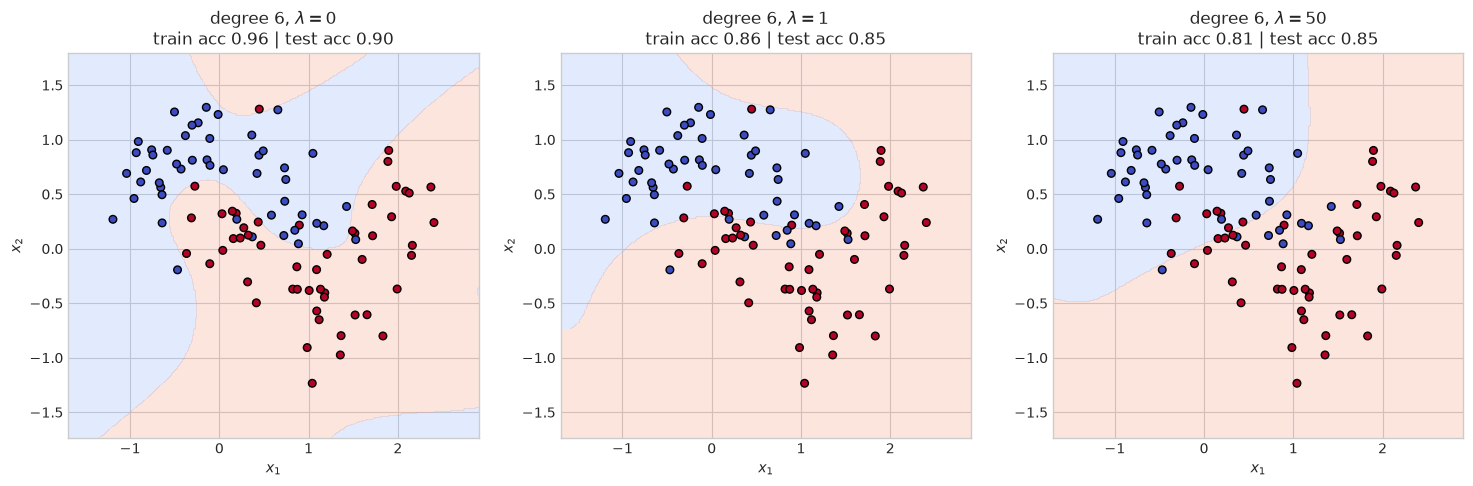

In [4]:
Xm, ym = make_moons(300, noise=0.3, random_state=1)
Xtr, ytr, Xte, yte = Xm[:100], ym[:100], Xm[100:], ym[100:]
d = 6
Z, transform = standardize(polynomial_features_2d(Xtr, d))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lam in zip(axes, [0.0, 1.0, 50.0], strict=True):
    th, _ = fit_logistic(add_bias(Z), ytr, alpha=1.0, lam=lam, max_iter=20000)
    f = lambda P, th=th: predict(th, add_bias(transform(polynomial_features_2d(P, d))))  # noqa: E731
    plot_decision_boundary(f, Xtr, ytr, ax=ax)
    ax.set_title(f"degree {d}, $\\lambda = {lam:g}$\ntrain acc {accuracy(ytr, f(Xtr)):.2f} | test acc {accuracy(yte, f(Xte)):.2f}")
plt.show()

## Summary

- The boundary $\theta^Tx = 0$ is where $h_\theta = 0.5$; it is linear in the features you give the model.
- Polynomial (or other) features make it curved; regularization $\lambda$ keeps it from chasing noise.
- Changing the threshold $\gamma$ trades false positives for false negatives → [03_classification_metrics](../03_classification_metrics/01_confusion_matrix_precision_recall_f1.ipynb).